In [10]:
# Q1.Load the Loan Prediction dataset and perform an initial analysis

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Loan prediction.csv")

# 1. Display first 10 records
print(df.head(10))

# 2. Features and Target Variable
print("\nFeatures:")
print(df.columns[:-1])

print("\nTarget Variable:")
print(df.columns[-1])

# 3. Number of records and attributes
print("\nShape:", df.shape)

# 4. Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 5. Statistical properties
print("\nStatistics:")
print(df.describe())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   
5  LP001011   Male     Yes          2      Graduate           Yes   
6  LP001013   Male     Yes          0  Not Graduate            No   
7  LP001014   Male     Yes         3+      Graduate            No   
8  LP001018   Male     Yes          2      Graduate            No   
9  LP001020   Male     Yes          1      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000         

In [11]:
# Q2. Perform data preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Fill missing categorical values
categorical = ['Gender','Married','Dependents','Self_Employed','Loan_Amount_Term','Credit_History']

for col in categorical:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill missing numerical values
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

# Drop Loan_ID
df.drop('Loan_ID', axis=1, inplace=True)

# Label Encoding
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Feature matrix and target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Standardization
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Preprocessing Completed")

Preprocessing Completed


/tmp/ipykernel_3753/2649567723.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_3753/2649567723.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

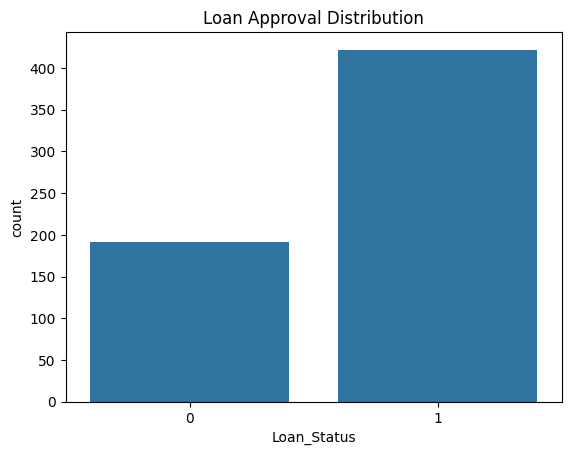

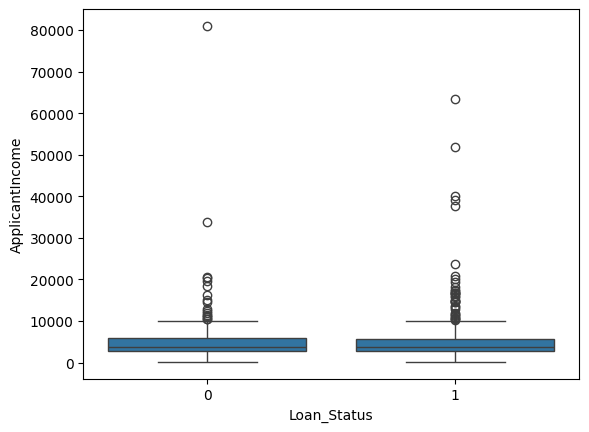

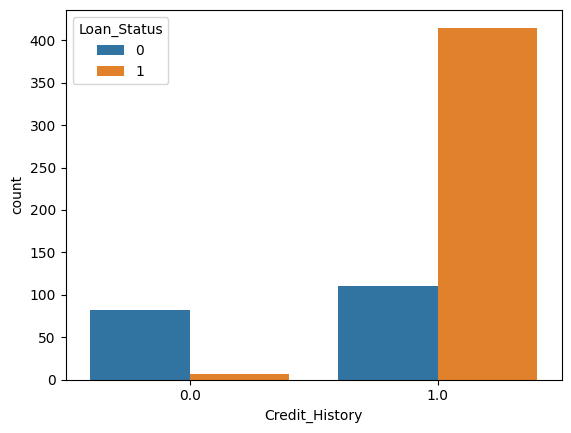

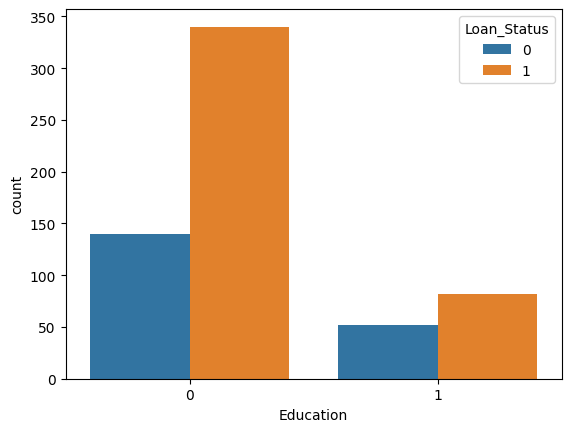

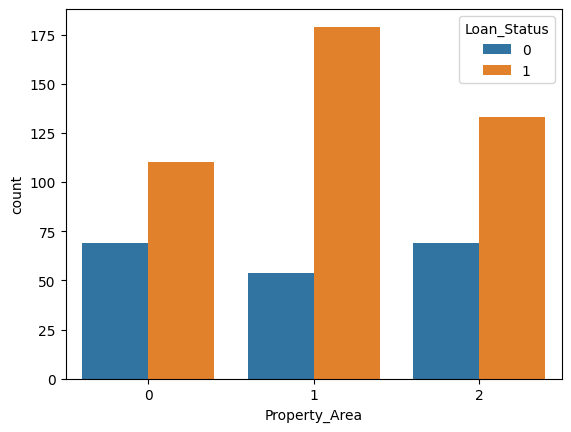

In [12]:
# Q3. Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# 1 Loan Approval Distribution
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

# 2 Applicant Income vs Loan Approval
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.show()

# 3 Credit History vs Loan Approval
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.show()

# 4 Education vs Loan Approval
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.show()

# 5 Property Area vs Loan Approval
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.show()

In [13]:
# Q4. Model Training and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results=[]

for name,model in models.items():

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ])

result_df=pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1 Score"])

print(result_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.861789   0.840000  0.988235  0.908108
1        Decision Tree  0.764228   0.825581  0.835294  0.830409
2        Random Forest  0.829268   0.847826  0.917647  0.881356


In [14]:
# Q5. Best Model Analysis
best_model = result_df.loc[result_df['Accuracy'].idxmax()]
print(best_model)

Model        Logistic Regression
Accuracy                0.861789
Precision                   0.84
Recall                  0.988235
F1 Score                0.908108
Name: 0, dtype: object


In [15]:
# Q6.Stratified 5-Fold Cross Validation
from sklearn.model_selection import StratifiedKFold,cross_val_score

skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

for name,model in models.items():

    scores=cross_val_score(model,X,y,cv=skf,scoring='accuracy')

    print("\n",name)
    print("Fold Accuracy:",scores)
    print("Mean Accuracy:",scores.mean())
    print("Standard Deviation:",scores.std())


 Logistic Regression
Fold Accuracy: [0.81300813 0.82113821 0.80487805 0.75609756 0.82786885]
Mean Accuracy: 0.8045981607357058
Standard Deviation: 0.025448821062939588

 Decision Tree
Fold Accuracy: [0.68292683 0.73170732 0.70731707 0.65853659 0.72131148]
Mean Accuracy: 0.700359856057577
Standard Deviation: 0.0265448033707344

 Random Forest
Fold Accuracy: [0.79674797 0.80487805 0.77235772 0.71544715 0.79508197]
Mean Accuracy: 0.7769025723044115
Standard Deviation: 0.03257109584873558


In [8]:
# Q7. Hyperparameter Tuning (Random Forest)
from sklearn.model_selection import GridSearchCV

params={
    'n_estimators':[50,100,200],
    'max_depth':[3,5,10],
    'min_samples_split':[2,5,10]
}

grid=GridSearchCV(RandomForestClassifier(random_state=42),
                  params,
                  cv=5,
                  scoring='accuracy')

grid.fit(X_train,y_train)

print("Best Parameters:",grid.best_params_)
print("Best CV Score:",grid.best_score_)

best_rf=grid.best_estimator_

pred=best_rf.predict(X_test)

print("Test Accuracy:",accuracy_score(y_test,pred))
print("Precision:",precision_score(y_test,pred))
print("Recall:",recall_score(y_test,pred))
print("F1 Score:",f1_score(y_test,pred))

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Best CV Score: 0.8004122861265719
Test Accuracy: 0.8536585365853658
Precision: 0.8316831683168316
Recall: 0.9882352941176471
F1 Score: 0.9032258064516129


In [9]:
# Q8. Bias-Variance Tradeoff
depths=[2,5,15]

results=[]

for d in depths:

    model=DecisionTreeClassifier(max_depth=d,random_state=42)

    model.fit(X_train,y_train)

    train_acc=model.score(X_train,y_train)

    test_acc=model.score(X_test,y_test)

    results.append([d,train_acc,test_acc])

bias_df=pd.DataFrame(results,columns=["Max Depth","Training Accuracy","Testing Accuracy"])

print(bias_df)

   Max Depth  Training Accuracy  Testing Accuracy
0          2           0.804481          0.853659
1          5           0.824847          0.821138
2         15           0.979633          0.764228
